In [2]:
# ============================================================
# IPL PLAYER PERFORMANCE PREDICTION
# NatWest Data Science Portfolio Project
# ============================================================

import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# ============================================================
# LOAD DATA
# ============================================================

file_path = r"C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\data\ipl_deliveries.csv\ipl_deliveries.csv"

print("Checking dataset path...")

if not os.path.isfile(file_path):
    raise FileNotFoundError(
        f"Dataset not found at:\n{file_path}\n\n"
        "Please check the file path."
    )

print("Dataset found successfully!")
print(f"File size: {os.path.getsize(file_path) / (1024**2):.2f} MB")

Checking dataset path...
Dataset found successfully!
File size: 34.22 MB


In [4]:
# ============================================================
# READ IPL BALL-BY-BALL DATA
# ============================================================

df = pd.read_csv(
    file_path,
    low_memory=False
)

# Convert date safely
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Dataset loaded successfully.
Rows: 295732
Columns: 21


,match_id,date,season,innings,batting_team,bowling_team,over,delivery,batter,non_striker,bowler,batter_runs,extras_runs,total_runs,wides,noballs,byes,legbyes,penalty,wicket_kind,player_out
0,1082591,2017-04-05,2017,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0.1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0.2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0.3,DA Warner,S Dhawan,TS Mills,4,0,4,0,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0.4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,0.5,DA Warner,S Dhawan,TS Mills,0,2,2,2,0,0,0,0,NaN,NaN


In [5]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDataset shape:")
print(df.shape)

Column names:
['match_id', 'date', 'season', 'innings', 'batting_team', 'bowling_team', 'over', 'delivery', 'batter', 'non_striker', 'bowler', 'batter_runs', 'extras_runs', 'total_runs', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_kind', 'player_out']

Data types:


match_id                 int64
date            datetime64[ns]
season                  object
innings                  int64
batting_team            object
bowling_team            object
over                     int64
delivery               float64
batter                  object
non_striker             object
bowler                  object
batter_runs              int64
extras_runs              int64
total_runs               int64
wides                    int64
noballs                  int64
byes                     int64
legbyes                  int64
penalty                  int64
wicket_kind             object
player_out              object
dtype: object


Missing values:


match_id             0
date                 0
season               0
innings              0
batting_team         0
bowling_team         0
over                 0
delivery             0
batter               0
non_striker          0
bowler               0
batter_runs          0
extras_runs          0
total_runs           0
wides                0
noballs              0
byes                 0
legbyes              0
penalty              0
wicket_kind     281027
player_out      281027
dtype: int64


Dataset shape:
(295732, 21)


In [6]:
# ============================================================
# BASIC DATA VALIDATION
# ============================================================

required_columns = [
    "match_id",
    "date",
    "season",
    "innings",
    "batting_team",
    "bowling_team",
    "over",
    "delivery",
    "batter",
    "non_striker",
    "bowler",
    "batter_runs",
    "extras_runs",
    "total_runs",
    "wides",
    "noballs",
    "byes",
    "legbyes",
    "penalty",
    "wicket_kind",
    "player_out"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are present.")

print("\nUnique matches:", df["match_id"].nunique())
print("Unique seasons:", df["season"].nunique())
print("Unique batters:", df["batter"].nunique())
print("Unique batting teams:", df["batting_team"].nunique())

All required columns are present.

Unique matches: 1243
Unique seasons: 19
Unique batters: 738
Unique batting teams: 19


In [7]:
# ============================================================
# DATA CLEANING
# ============================================================

numeric_columns = [
    "innings",
    "over",
    "delivery",
    "batter_runs",
    "extras_runs",
    "total_runs",
    "wides",
    "noballs",
    "byes",
    "legbyes",
    "penalty"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Replace missing numeric values with zero
df[numeric_columns] = df[numeric_columns].fillna(0)

# Remove rows where essential identifiers are missing
df = df.dropna(
    subset=[
        "match_id",
        "date",
        "batter",
        "batting_team",
        "bowling_team"
    ]
)

# Sort chronologically
df = df.sort_values(
    [
        "date",
        "match_id",
        "innings",
        "over",
        "delivery"
    ]
).reset_index(drop=True)

print("Rows after cleaning:", len(df))

Rows after cleaning: 295732


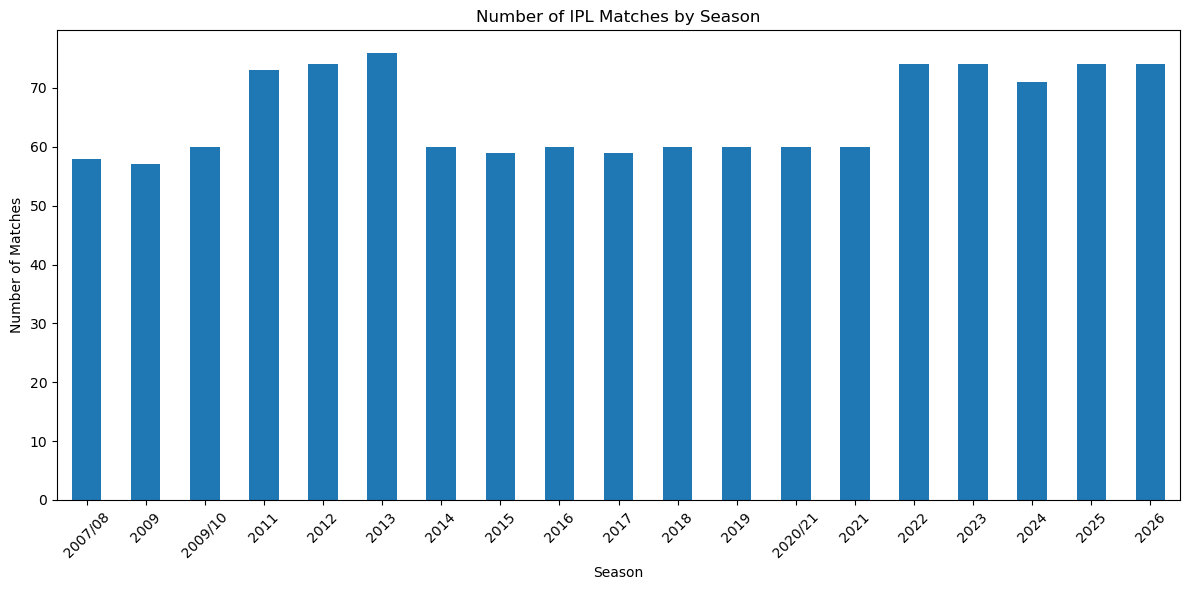

In [8]:
# ============================================================
# EDA — MATCHES BY SEASON
# ============================================================

matches_by_season = (
    df.groupby("season")["match_id"]
    .nunique()
)

plt.figure(figsize=(12, 6))

matches_by_season.plot(
    kind="bar"
)

plt.title("Number of IPL Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

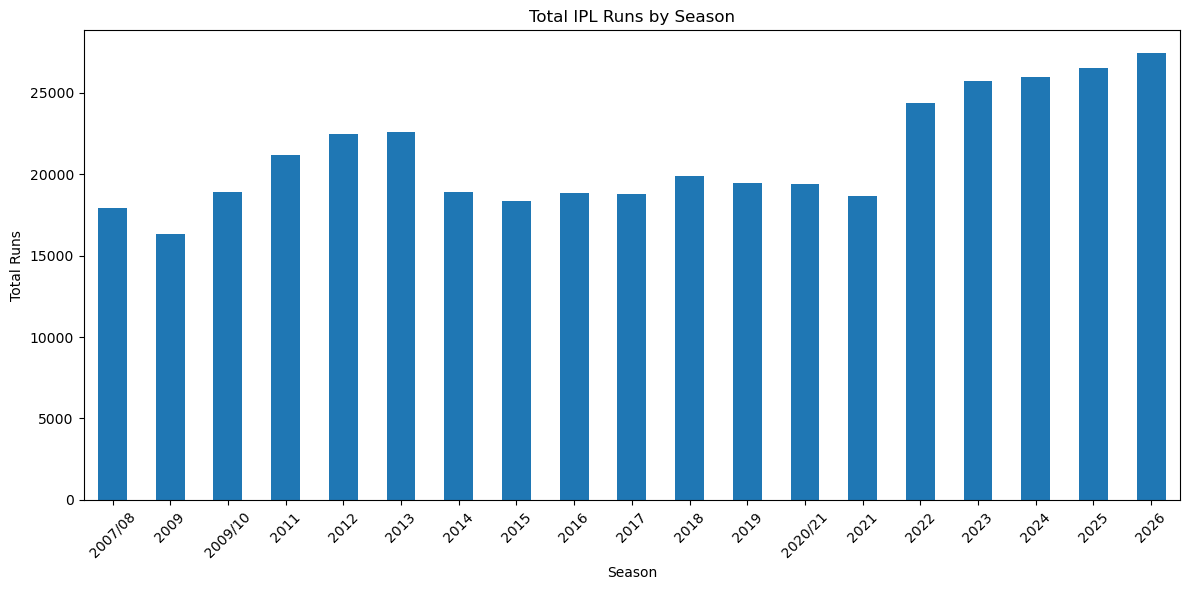

In [9]:
# ============================================================
# EDA — TOTAL RUNS BY SEASON
# ============================================================

runs_by_season = (
    df.groupby("season")["total_runs"]
    .sum()
)

plt.figure(figsize=(12, 6))

runs_by_season.plot(
    kind="bar"
)

plt.title("Total IPL Runs by Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CREATE PLAYER-MATCH DATASET
# ============================================================

# Legal balls faced:
# wides and no-balls are excluded from legal deliveries
df["legal_ball"] = (
    (df["wides"] == 0) &
    (df["noballs"] == 0)
)

# Aggregate one batter's performance in each innings
player_match = (
    df.groupby(
        [
            "match_id",
            "date",
            "season",
            "innings",
            "batting_team",
            "bowling_team",
            "batter"
        ],
        as_index=False
    )
    .agg(
        runs=("batter_runs", "sum"),

        balls_faced=("legal_ball", "sum"),

        fours=(
            "batter_runs",
            lambda x: (x == 4).sum()
        ),

        sixes=(
            "batter_runs",
            lambda x: (x == 6).sum()
        )
    )
)

print("Player-match dataset created.")
print("Rows:", len(player_match))
print("Unique players:", player_match["batter"].nunique())
print("Unique matches:", player_match["match_id"].nunique())

display(player_match.head(10))

Player-match dataset created.
Rows: 18842
Unique players: 738
Unique matches: 1243


,match_id,date,season,innings,batting_team,bowling_team,batter,runs,balls_faced,fours,sixes
0,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,158,73,10,13
1,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,DJ Hussey,12,12,1,0
2,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,Mohammad Hafeez,5,3,1,0
3,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,20,20,1,1
4,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,10,12,2,0
5,335982,2008-04-18,2007/08,2,Royal Challengers Bangalore,Kolkata Knight Riders,AA Noffke,9,10,1,0
6,335982,2008-04-18,2007/08,2,Royal Challengers Bangalore,Kolkata Knight Riders,B Akhil,0,2,0,0
7,335982,2008-04-18,2007/08,2,Royal Challengers Bangalore,Kolkata Knight Riders,CL White,6,10,0,0
8,335982,2008-04-18,2007/08,2,Royal Challengers Bangalore,Kolkata Knight Riders,JH Kallis,8,7,0,1
9,335982,2008-04-18,2007/08,2,Royal Challengers Bangalore,Kolkata Knight Riders,MV Boucher,7,9,1,0


In [11]:
# ============================================================
# STRIKE RATE
# ============================================================

player_match["strike_rate"] = np.where(
    player_match["balls_faced"] > 0,
    (
        player_match["runs"] /
        player_match["balls_faced"]
    ) * 100,
    0
)

display(
    player_match[
        [
            "batter",
            "runs",
            "balls_faced",
            "strike_rate",
            "fours",
            "sixes"
        ]
    ].head(10)
)

,batter,runs,balls_faced,strike_rate,fours,sixes
0,BB McCullum,158,73,216.438356,10,13
1,DJ Hussey,12,12,100.000000,1,0
2,Mohammad Hafeez,5,3,166.666667,1,0
3,RT Ponting,20,20,100.000000,1,1
4,SC Ganguly,10,12,83.333333,2,0
5,AA Noffke,9,10,90.000000,1,0
6,B Akhil,0,2,0.000000,0,0
7,CL White,6,10,60.000000,0,0
8,JH Kallis,8,7,114.285714,0,1
9,MV Boucher,7,9,77.777778,1,0


In [12]:
# ============================================================
# OPPONENT
# ============================================================

player_match["opponent"] = (
    player_match["bowling_team"]
)

# Sort chronologically
player_match = (
    player_match
    .sort_values(
        [
            "date",
            "match_id",
            "innings",
            "batter"
        ]
    )
    .reset_index(drop=True)
)

display(player_match.head())

,match_id,date,season,innings,batting_team,bowling_team,batter,runs,balls_faced,fours,sixes,strike_rate,opponent
0,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,158,73,10,13,216.438356,Royal Challengers Bangalore
1,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,DJ Hussey,12,12,1,0,100.000000,Royal Challengers Bangalore
2,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,Mohammad Hafeez,5,3,1,0,166.666667,Royal Challengers Bangalore
3,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,20,20,1,1,100.000000,Royal Challengers Bangalore
4,335982,2008-04-18,2007/08,1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,10,12,2,0,83.333333,Royal Challengers Bangalore


In [13]:
# ============================================================
# HISTORICAL PERFORMANCE FEATURES
# ============================================================

# Sort by player and time
player_match = (
    player_match
    .sort_values(
        [
            "batter",
            "date",
            "match_id"
        ]
    )
    .reset_index(drop=True)
)

# Previous match runs
player_match["previous_runs"] = (
    player_match
    .groupby("batter")["runs"]
    .shift(1)
)

# Previous match strike rate
player_match["previous_strike_rate"] = (
    player_match
    .groupby("batter")["strike_rate"]
    .shift(1)
)

display(
    player_match[
        [
            "batter",
            "date",
            "runs",
            "previous_runs",
            "previous_strike_rate"
        ]
    ].head(20)
)

,batter,date,runs,previous_runs,previous_strike_rate
0,A Ashish Reddy,2012-04-29,10,NaN,NaN
1,A Ashish Reddy,2012-05-04,3,10.0,100.000000
2,A Ashish Reddy,2012-05-08,8,3.0,100.000000
3,A Ashish Reddy,2012-05-18,10,8.0,100.000000
4,A Ashish Reddy,2012-05-20,4,10.0,250.000000
5,A Ashish Reddy,2013-04-05,7,4.0,100.000000
6,A Ashish Reddy,2013-04-07,14,7.0,175.000000
7,A Ashish Reddy,2013-04-09,3,14.0,116.666667
8,A Ashish Reddy,2013-04-12,16,3.0,75.000000
9,A Ashish Reddy,2013-04-14,4,16.0,177.777778


In [14]:
# ============================================================
# CAREER FEATURES BEFORE CURRENT MATCH
# ============================================================

# Career average before current match
player_match["career_average_before_match"] = (
    player_match
    .groupby("batter")["runs"]
    .transform(
        lambda x:
        x.shift(1)
        .expanding()
        .mean()
    )
)

# Career strike rate before current match
player_match["career_strike_rate_before_match"] = (
    player_match
    .groupby("batter")["strike_rate"]
    .transform(
        lambda x:
        x.shift(1)
        .expanding()
        .mean()
    )
)

# Number of previous matches
player_match["previous_matches"] = (
    player_match
    .groupby("batter")
    .cumcount()
)

display(
    player_match[
        [
            "batter",
            "runs",
            "career_average_before_match",
            "career_strike_rate_before_match",
            "previous_matches"
        ]
    ].head(20)
)

,batter,runs,career_average_before_match,career_strike_rate_before_match,previous_matches
0,A Ashish Reddy,10,NaN,NaN,0
1,A Ashish Reddy,3,10.000000,100.000000,1
2,A Ashish Reddy,8,6.500000,100.000000,2
3,A Ashish Reddy,10,7.000000,100.000000,3
4,A Ashish Reddy,4,7.750000,137.500000,4
5,A Ashish Reddy,7,7.000000,130.000000,5
6,A Ashish Reddy,14,7.000000,137.500000,6
7,A Ashish Reddy,3,8.000000,134.523810,7
8,A Ashish Reddy,16,7.375000,127.083333,8
9,A Ashish Reddy,4,8.333333,132.716049,9


In [15]:
# ============================================================
# RECENT FORM
# ============================================================

# Previous 5-match average
player_match["recent_5_match_average"] = (
    player_match
    .groupby("batter")["runs"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=5,
            min_periods=1
        )
        .mean()
    )
)

# Previous 10-match average
player_match["recent_10_match_average"] = (
    player_match
    .groupby("batter")["runs"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=10,
            min_periods=1
        )
        .mean()
    )
)

display(
    player_match[
        [
            "batter",
            "runs",
            "recent_5_match_average",
            "recent_10_match_average"
        ]
    ].head(20)
)

,batter,runs,recent_5_match_average,recent_10_match_average
0,A Ashish Reddy,10,NaN,NaN
1,A Ashish Reddy,3,10.00,10.000000
2,A Ashish Reddy,8,6.50,6.500000
3,A Ashish Reddy,10,7.00,7.000000
4,A Ashish Reddy,4,7.75,7.750000
5,A Ashish Reddy,7,7.00,7.000000
6,A Ashish Reddy,14,6.40,7.000000
7,A Ashish Reddy,3,8.60,8.000000
8,A Ashish Reddy,16,7.60,7.375000
9,A Ashish Reddy,4,8.80,8.333333


In [16]:
# ============================================================
# HISTORICAL PERFORMANCE AGAINST OPPONENT
# ============================================================

player_match["opponent_average_before_match"] = (
    player_match
    .groupby(
        [
            "batter",
            "opponent"
        ]
    )["runs"]
    .transform(
        lambda x:
        x.shift(1)
        .expanding()
        .mean()
    )
)

display(
    player_match[
        [
            "batter",
            "opponent",
            "runs",
            "opponent_average_before_match"
        ]
    ].head(20)
)

,batter,opponent,runs,opponent_average_before_match
0,A Ashish Reddy,Mumbai Indians,10,NaN
1,A Ashish Reddy,Chennai Super Kings,3,NaN
2,A Ashish Reddy,Kings XI Punjab,8,NaN
3,A Ashish Reddy,Rajasthan Royals,10,NaN
4,A Ashish Reddy,Royal Challengers Bangalore,4,NaN
5,A Ashish Reddy,Pune Warriors,7,NaN
6,A Ashish Reddy,Royal Challengers Bangalore,14,4.0
7,A Ashish Reddy,Royal Challengers Bangalore,3,9.0
8,A Ashish Reddy,Delhi Daredevils,16,NaN
9,A Ashish Reddy,Kolkata Knight Riders,4,NaN


In [17]:
# ============================================================
# HISTORICAL BOUNDARY PERFORMANCE
# ============================================================

player_match["previous_fours"] = (
    player_match
    .groupby("batter")["fours"]
    .shift(1)
)

player_match["previous_sixes"] = (
    player_match
    .groupby("batter")["sixes"]
    .shift(1)
)

player_match["recent_5_fours"] = (
    player_match
    .groupby("batter")["fours"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(5, min_periods=1)
        .mean()
    )
)

player_match["recent_5_sixes"] = (
    player_match
    .groupby("batter")["sixes"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(5, min_periods=1)
        .mean()
    )
)

In [18]:
# ============================================================
# HANDLE HISTORICAL MISSING VALUES
# ============================================================

historical_columns = [
    "previous_runs",
    "previous_strike_rate",
    "career_average_before_match",
    "career_strike_rate_before_match",
    "recent_5_match_average",
    "recent_10_match_average",
    "opponent_average_before_match",
    "previous_fours",
    "previous_sixes",
    "recent_5_fours",
    "recent_5_sixes"
]

player_match[historical_columns] = (
    player_match[historical_columns]
    .fillna(0)
)

print("Missing historical values handled.")

Missing historical values handled.


In [19]:
# ============================================================
# FINAL PLAYER-MATCH DATASET
# ============================================================

print("Player-match dataset shape:")
print(player_match.shape)

print("\nUnique players:")
print(player_match["batter"].nunique())

print("\nUnique matches:")
print(player_match["match_id"].nunique())

print("\nMissing values:")
display(
    player_match.isnull().sum()
)

display(
    player_match.head(15)
)

Player-match dataset shape:
(18842, 25)

Unique players:
738

Unique matches:
1243

Missing values:


match_id                           0
date                               0
season                             0
innings                            0
batting_team                       0
bowling_team                       0
batter                             0
runs                               0
balls_faced                        0
fours                              0
sixes                              0
strike_rate                        0
opponent                           0
previous_runs                      0
previous_strike_rate               0
career_average_before_match        0
career_strike_rate_before_match    0
previous_matches                   0
recent_5_match_average             0
recent_10_match_average            0
opponent_average_before_match      0
previous_fours                     0
previous_sixes                     0
recent_5_fours                     0
recent_5_sixes                     0
dtype: int64

,match_id,date,season,innings,batting_team,bowling_team,batter,runs,balls_faced,fours,sixes,strike_rate,opponent,previous_runs,previous_strike_rate,career_average_before_match,career_strike_rate_before_match,previous_matches,recent_5_match_average,recent_10_match_average,opponent_average_before_match,previous_fours,previous_sixes,recent_5_fours,recent_5_sixes
0,548346,2012-04-29,2012,1,Deccan Chargers,Mumbai Indians,A Ashish Reddy,10,10,0,1,100.000000,Mumbai Indians,0.0,0.000000,0.000000,0.000000,0,0.00,0.000000,0.0,0.0,0.0,0.000000,0.000000
1,548352,2012-05-04,2012,2,Deccan Chargers,Chennai Super Kings,A Ashish Reddy,3,3,0,0,100.000000,Chennai Super Kings,10.0,100.000000,10.000000,100.000000,1,10.00,10.000000,0.0,0.0,1.0,0.000000,1.000000
2,548359,2012-05-08,2012,2,Deccan Chargers,Kings XI Punjab,A Ashish Reddy,8,8,1,0,100.000000,Kings XI Punjab,3.0,100.000000,6.500000,100.000000,2,6.50,6.500000,0.0,0.0,0.0,0.000000,0.500000
3,548373,2012-05-18,2012,2,Deccan Chargers,Rajasthan Royals,A Ashish Reddy,10,4,2,0,250.000000,Rajasthan Royals,8.0,100.000000,7.000000,100.000000,3,7.00,7.000000,0.0,1.0,0.0,0.333333,0.333333
4,548376,2012-05-20,2012,1,Deccan Chargers,Royal Challengers Bangalore,A Ashish Reddy,4,4,0,0,100.000000,Royal Challengers Bangalore,10.0,250.000000,7.750000,137.500000,4,7.75,7.750000,0.0,2.0,0.0,0.750000,0.250000
5,598000,2013-04-05,2013,1,Sunrisers Hyderabad,Pune Warriors,A Ashish Reddy,7,4,1,0,175.000000,Pune Warriors,4.0,100.000000,7.000000,130.000000,5,7.00,7.000000,0.0,0.0,0.0,0.600000,0.200000
6,598004,2013-04-07,2013,2,Sunrisers Hyderabad,Royal Challengers Bangalore,A Ashish Reddy,14,12,0,1,116.666667,Royal Challengers Bangalore,7.0,175.000000,7.000000,137.500000,6,6.40,7.000000,4.0,1.0,0.0,0.800000,0.000000
7,598048,2013-04-09,2013,1,Sunrisers Hyderabad,Royal Challengers Bangalore,A Ashish Reddy,3,4,0,0,75.000000,Royal Challengers Bangalore,14.0,116.666667,8.000000,134.523810,7,8.60,8.000000,9.0,0.0,1.0,0.800000,0.200000
8,598010,2013-04-12,2013,2,Sunrisers Hyderabad,Delhi Daredevils,A Ashish Reddy,16,9,2,0,177.777778,Delhi Daredevils,3.0,75.000000,7.375000,127.083333,8,7.60,7.375000,0.0,0.0,0.0,0.600000,0.200000
9,598013,2013-04-14,2013,2,Sunrisers Hyderabad,Kolkata Knight Riders,A Ashish Reddy,4,5,0,0,80.000000,Kolkata Knight Riders,16.0,177.777778,8.333333,132.716049,9,8.80,8.333333,0.0,2.0,0.0,0.600000,0.200000


In [20]:
# ============================================================
# SAVE PROCESSED DATASET
# ============================================================

output_file = (
    r"C:\Masters\GitHub"
    r"\Cricket_Player_Performance_NatWest_GitHub_Project"
    r"\data\player_match_model.csv"
)

player_match.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

Saved successfully:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\data\player_match_model.csv


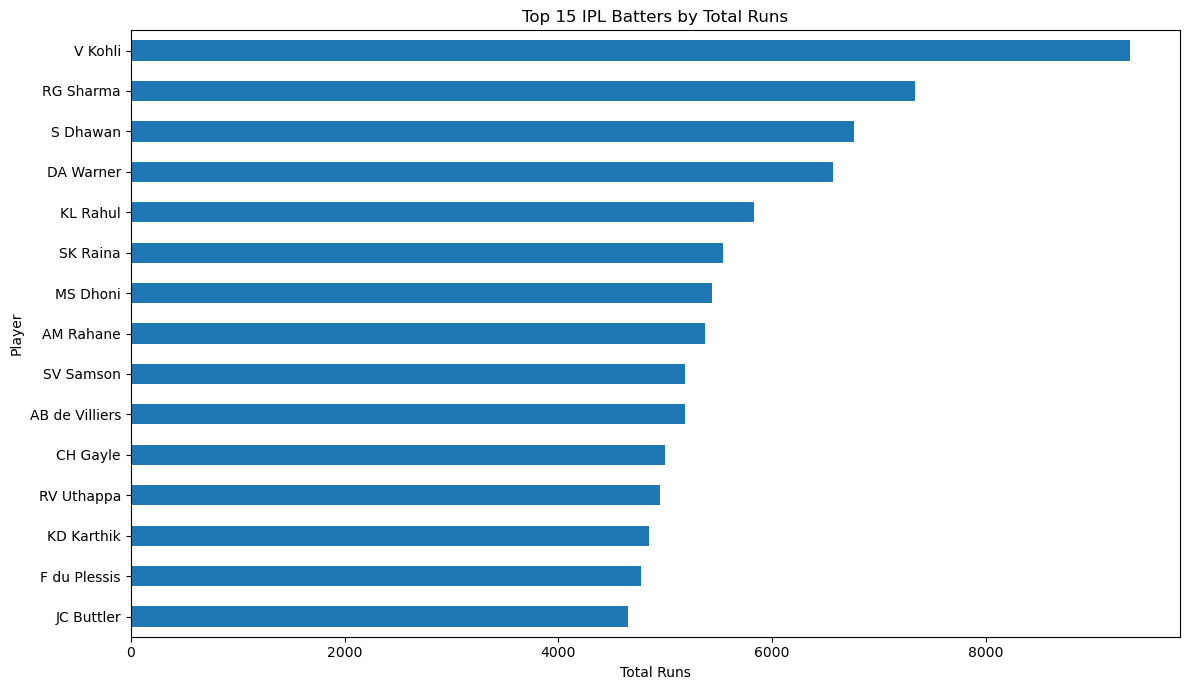

In [21]:
# ============================================================
# EDA — TOP IPL BATTERS
# ============================================================

top_players = (
    player_match
    .groupby("batter")["runs"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

top_players.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 IPL Batters by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

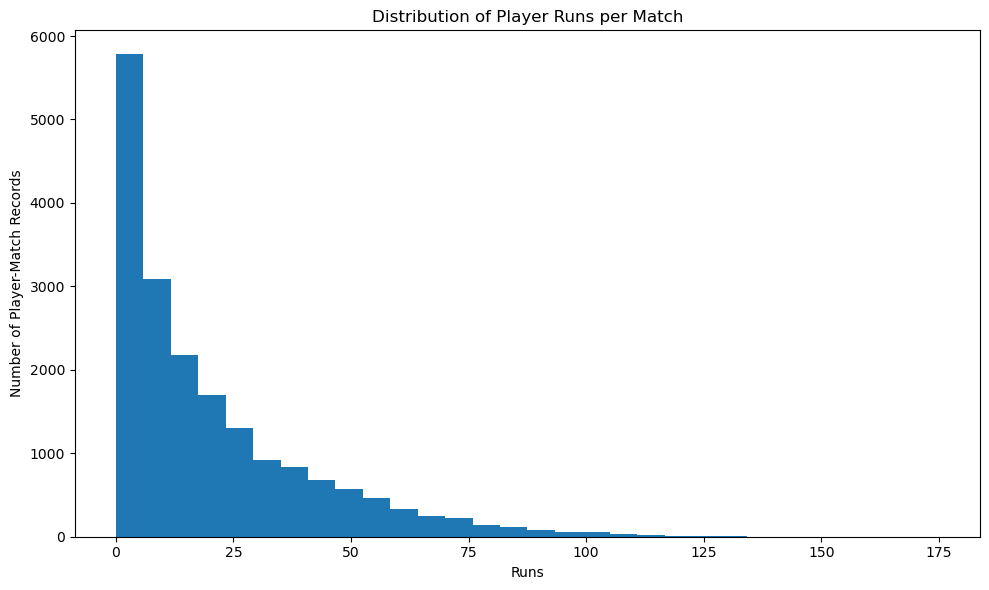

In [22]:
# ============================================================
# EDA — RUN DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    player_match["runs"],
    bins=30
)

plt.title("Distribution of Player Runs per Match")
plt.xlabel("Runs")
plt.ylabel("Number of Player-Match Records")

plt.tight_layout()
plt.show()

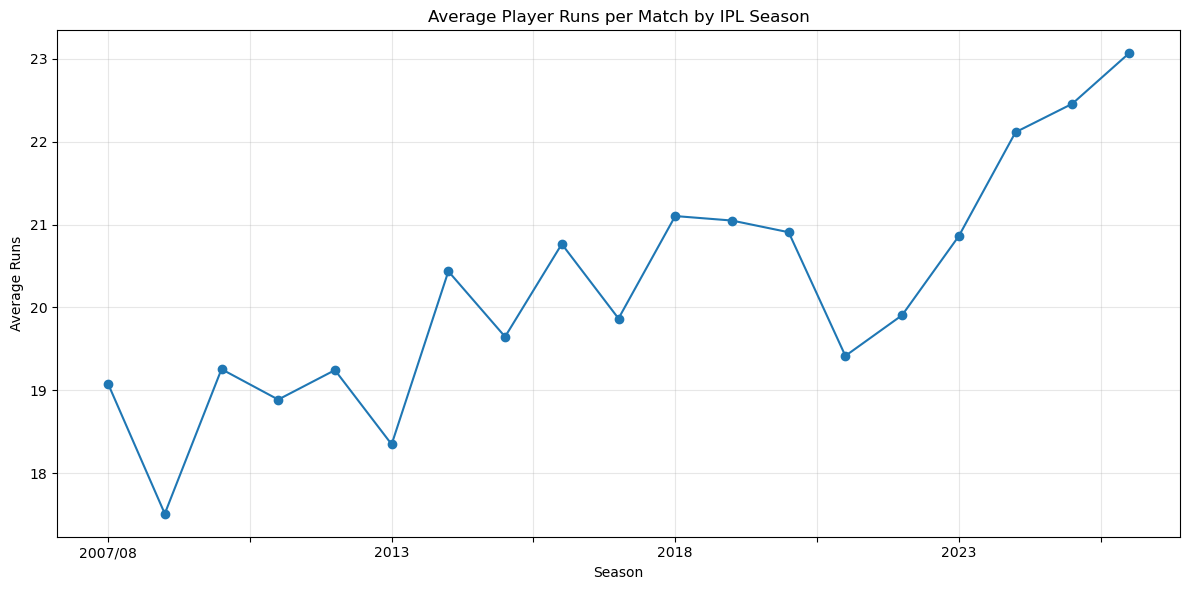

In [23]:
# ============================================================
# EDA — AVERAGE RUNS BY SEASON
# ============================================================

average_runs_season = (
    player_match
    .groupby("season")["runs"]
    .mean()
)

plt.figure(figsize=(12, 6))

average_runs_season.plot(
    marker="o"
)

plt.title("Average Player Runs per Match by IPL Season")
plt.xlabel("Season")
plt.ylabel("Average Runs")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

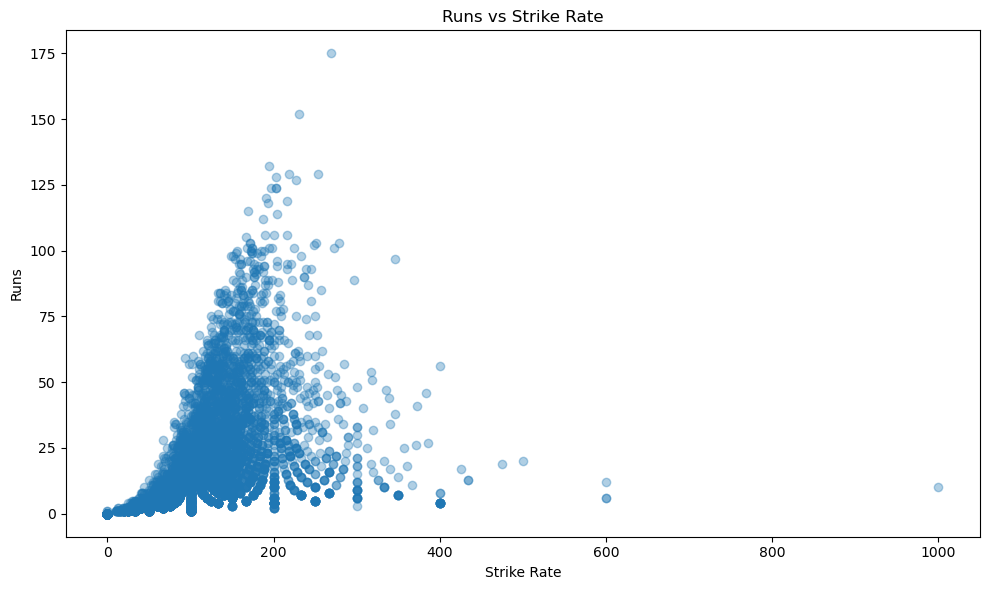

In [24]:
# ============================================================
# EDA — RUNS VS STRIKE RATE
# ============================================================

sample = player_match.sample(
    min(5000, len(player_match)),
    random_state=42
)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample["strike_rate"],
    sample["runs"],
    alpha=0.35
)

plt.title("Runs vs Strike Rate")
plt.xlabel("Strike Rate")
plt.ylabel("Runs")

plt.tight_layout()
plt.show()

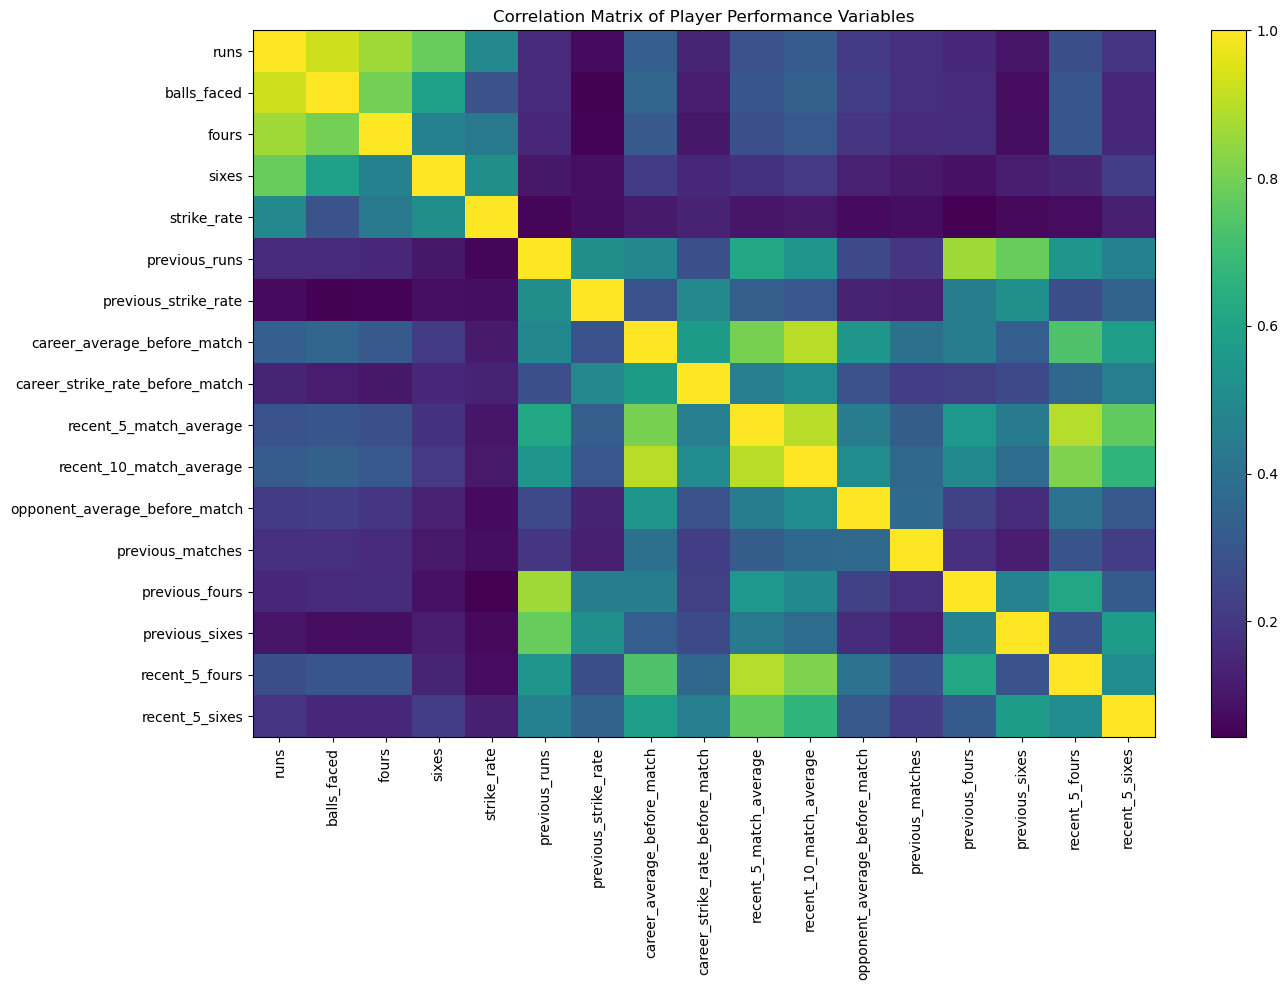

In [25]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_columns = [
    "runs",
    "balls_faced",
    "fours",
    "sixes",
    "strike_rate",
    "previous_runs",
    "previous_strike_rate",
    "career_average_before_match",
    "career_strike_rate_before_match",
    "recent_5_match_average",
    "recent_10_match_average",
    "opponent_average_before_match",
    "previous_matches",
    "previous_fours",
    "previous_sixes",
    "recent_5_fours",
    "recent_5_sixes"
]

correlation_matrix = (
    player_match[correlation_columns]
    .corr()
)

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Player Performance Variables")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# MACHINE LEARNING DATASET
# ============================================================

model_df = player_match.copy()

# Sort chronologically
model_df = (
    model_df
    .sort_values(
        ["date", "match_id"]
    )
    .reset_index(drop=True)
)

# Target
target = "runs"

# Features known before / at match start
features = [
    "batter",
    "batting_team",
    "opponent",
    "season",
    "innings",
    "previous_runs",
    "previous_strike_rate",
    "career_average_before_match",
    "career_strike_rate_before_match",
    "recent_5_match_average",
    "recent_10_match_average",
    "opponent_average_before_match",
    "previous_matches",
    "previous_fours",
    "previous_sixes",
    "recent_5_fours",
    "recent_5_sixes"
]

X = model_df[features]
y = model_df[target]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['batter', 'batting_team', 'opponent', 'season', 'innings', 'previous_runs', 'previous_strike_rate', 'career_average_before_match', 'career_strike_rate_before_match', 'recent_5_match_average', 'recent_10_match_average', 'opponent_average_before_match', 'previous_matches', 'previous_fours', 'previous_sixes', 'recent_5_fours', 'recent_5_sixes']

X shape: (18842, 17)
y shape: (18842,)


In [27]:
# ============================================================
# TIME-BASED TRAIN / TEST SPLIT
# ============================================================

split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "\nTraining period:",
    model_df.iloc[0]["date"].date(),
    "to",
    model_df.iloc[split_index - 1]["date"].date()
)

print(
    "Testing period:",
    model_df.iloc[split_index]["date"].date(),
    "to",
    model_df.iloc[-1]["date"].date()
)

Training rows: 15073
Testing rows: 3769

Training period: 2008-04-18 to 2023-05-05
Testing period: 2023-05-05 to 2026-05-31


In [30]:
# ============================================================
# CELL 27 — PREPROCESSING
# ============================================================

# Categorical features
categorical_features = [
    "batter",
    "batting_team",
    "opponent",
    "season"
]

# Numerical features
numerical_features = [
    "innings",
    "previous_runs",
    "previous_strike_rate",
    "career_average_before_match",
    "career_strike_rate_before_match",
    "recent_5_match_average",
    "recent_10_match_average",
    "opponent_average_before_match",
    "previous_matches",
    "previous_fours",
    "previous_sixes",
    "recent_5_fours",
    "recent_5_sixes"
]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        
        # ----------------------------------------
        # CATEGORICAL FEATURES
        # ----------------------------------------
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            categorical_features
        ),

        # ----------------------------------------
        # NUMERICAL FEATURES
        # ----------------------------------------
        (
            "numerical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]
            ),
            numerical_features
        )
    ]
)

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nPreprocessing pipeline created successfully.")

Categorical features:
['batter', 'batting_team', 'opponent', 'season']

Numerical features:
['innings', 'previous_runs', 'previous_strike_rate', 'career_average_before_match', 'career_strike_rate_before_match', 'recent_5_match_average', 'recent_10_match_average', 'opponent_average_before_match', 'previous_matches', 'previous_fours', 'previous_sixes', 'recent_5_fours', 'recent_5_sixes']

Preprocessing pipeline created successfully.


In [31]:
# ============================================================
# LINEAR REGRESSION
# ============================================================

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = (
    linear_model.predict(X_test)
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("LINEAR REGRESSION")
print("--------------------------")
print(f"MAE  : {linear_mae:.3f}")
print(f"RMSE : {linear_rmse:.3f}")
print(f"R²   : {linear_r2:.3f}")

LINEAR REGRESSION
--------------------------
MAE  : 16.825
RMSE : 23.721
R²   : -0.009


In [32]:
# ============================================================
# RANDOM FOREST REGRESSION
# ============================================================

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = (
    random_forest_model.predict(X_test)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("RANDOM FOREST")
print("--------------------------")
print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

RANDOM FOREST
--------------------------
MAE  : 16.280
RMSE : 22.230
R²   : 0.114


In [33]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

display(
    results.round(3)
)

,Model,MAE,RMSE,R2
0,Linear Regression,16.825,23.721,-0.009
1,Random Forest,16.280,22.230,0.114


In [34]:
# ============================================================
# TIME-SERIES CROSS-VALIDATION
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)

cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

cv_mae = -cv_scores

print("Random Forest Time-Series Cross-Validation")
print("-------------------------------------------")

for i, score in enumerate(
    cv_mae,
    start=1
):
    print(
        f"Fold {i}: MAE = {score:.3f}"
    )

print(
    f"\nMean CV MAE: {cv_mae.mean():.3f}"
)

print(
    f"Std CV MAE : {cv_mae.std():.3f}"
)

Random Forest Time-Series Cross-Validation
-------------------------------------------
Fold 1: MAE = 14.959
Fold 2: MAE = 14.741
Fold 3: MAE = 15.516
Fold 4: MAE = 15.629
Fold 5: MAE = 14.967

Mean CV MAE: 15.163
Std CV MAE : 0.346


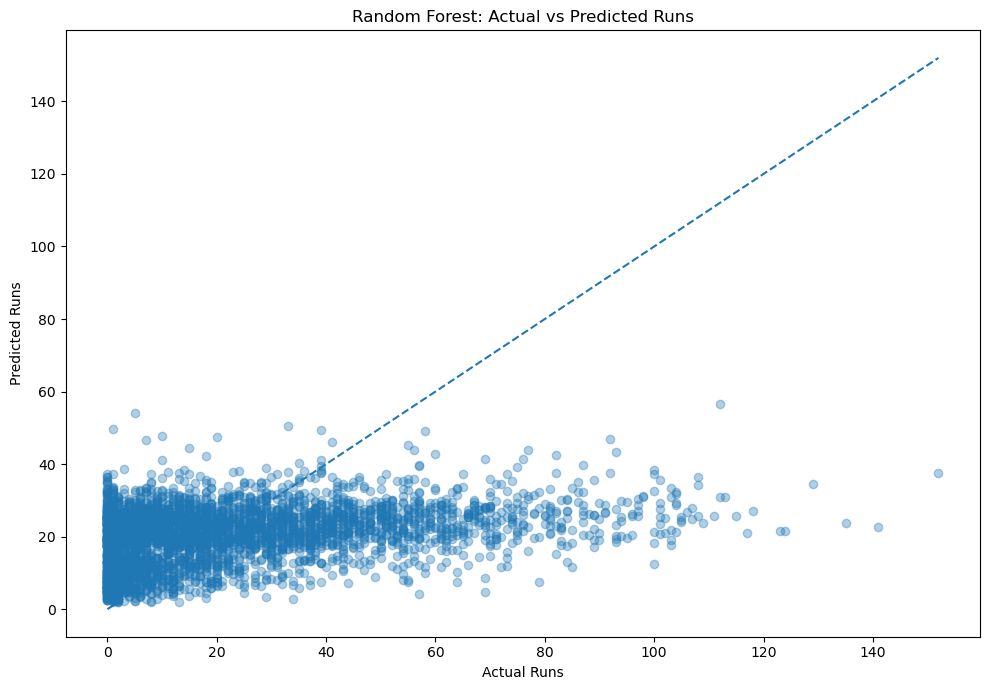

In [35]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.35
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    rf_predictions.min()
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    "Random Forest: Actual vs Predicted Runs"
)

plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")

plt.tight_layout()
plt.show()

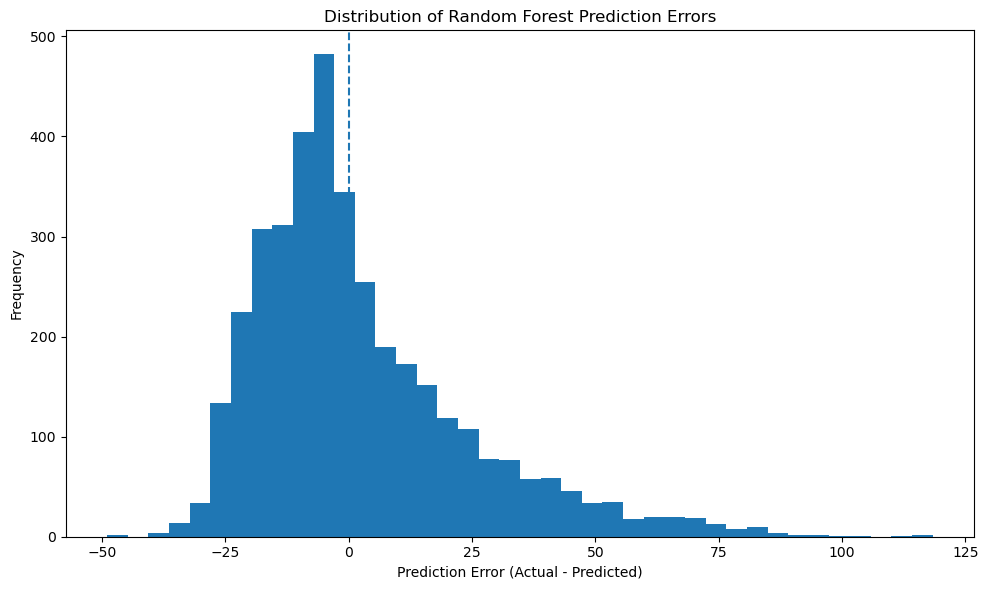

In [36]:
# ============================================================
# PREDICTION ERRORS
# ============================================================

errors = (
    y_test.values -
    rf_predictions
)

plt.figure(figsize=(10, 6))

plt.hist(
    errors,
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of Random Forest Prediction Errors"
)

plt.xlabel(
    "Prediction Error (Actual - Predicted)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

rf_pipeline = random_forest_model.named_steps[
    "model"
]

rf_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

# Get transformed feature names
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importances = (
    rf_pipeline.feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(20)
)

display(feature_importance)

,Feature,Importance
685,numerical__career_average_before_match,0.303266
688,numerical__recent_10_match_average,0.073073
686,numerical__career_strike_rate_before_match,0.071691
690,numerical__previous_matches,0.057706
689,numerical__opponent_average_before_match,0.056808
684,numerical__previous_strike_rate,0.054969
687,numerical__recent_5_match_average,0.048156
683,numerical__previous_runs,0.043932
693,numerical__recent_5_fours,0.040253
694,numerical__recent_5_sixes,0.030183


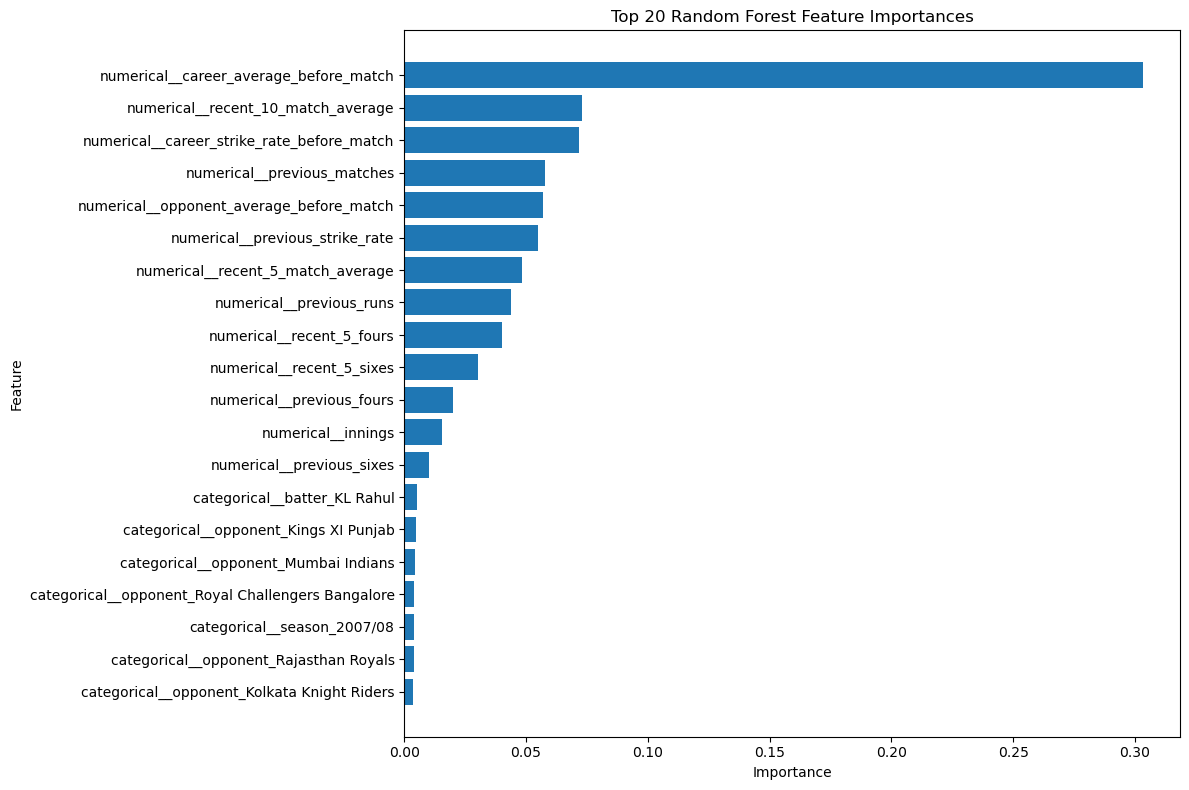

In [38]:
# ============================================================
# FEATURE IMPORTANCE VISUALISATION
# ============================================================

importance_plot = (
    feature_importance
    .sort_values("Importance")
)

plt.figure(figsize=(12, 8))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"]
)

plt.title(
    "Top 20 Random Forest Feature Importances"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# PREDICTION RESULTS
# ============================================================

prediction_results = model_df.iloc[
    split_index:
].copy()

prediction_results[
    "predicted_runs"
] = rf_predictions

prediction_results[
    "prediction_error"
] = (
    prediction_results["runs"] -
    prediction_results["predicted_runs"]
)

prediction_results[
    "absolute_error"
] = (
    prediction_results["prediction_error"]
    .abs()
)

display(
    prediction_results[
        [
            "date",
            "batter",
            "batting_team",
            "opponent",
            "runs",
            "predicted_runs",
            "prediction_error",
            "absolute_error"
        ]
    ].head(20)
)

,date,batter,batting_team,opponent,runs,predicted_runs,prediction_error,absolute_error
15073,2023-05-05,TA Boult,Rajasthan Royals,Gujarat Titans,15,3.589118,11.410882,11.410882
15074,2023-05-05,WP Saha,Gujarat Titans,Rajasthan Royals,41,23.047879,17.952121,17.952121
15075,2023-05-05,YBK Jaiswal,Rajasthan Royals,Gujarat Titans,14,38.454277,-24.454277,24.454277
15076,2023-05-06,AM Rahane,Chennai Super Kings,Mumbai Indians,21,26.979869,-5.979869,5.979869
15077,2023-05-06,AT Rayudu,Chennai Super Kings,Mumbai Indians,12,20.901187,-8.901187,8.901187
15078,2023-05-06,Arshad Khan,Mumbai Indians,Chennai Super Kings,1,10.684765,-9.684765,9.684765
15079,2023-05-06,C Green,Mumbai Indians,Chennai Super Kings,6,25.443362,-19.443362,19.443362
15080,2023-05-06,DP Conway,Chennai Super Kings,Mumbai Indians,44,33.680146,10.319854,10.319854
15081,2023-05-06,Ishan Kishan,Mumbai Indians,Chennai Super Kings,7,27.282343,-20.282343,20.282343
15082,2023-05-06,JC Archer,Mumbai Indians,Chennai Super Kings,3,9.230699,-6.230699,6.230699


In [40]:
# ============================================================
# CLOSEST PREDICTIONS
# ============================================================

closest_predictions = (
    prediction_results
    .sort_values("absolute_error")
    [
        [
            "date",
            "batter",
            "batting_team",
            "opponent",
            "runs",
            "predicted_runs",
            "absolute_error"
        ]
    ]
    .head(15)
)

display(
    closest_predictions
)

,date,batter,batting_team,opponent,runs,predicted_runs,absolute_error
16448,2024-05-14,Ravi Bishnoi,Lucknow Super Giants,Delhi Capitals,2,1.999133,0.000867
15829,2024-04-10,M Shahrukh Khan,Gujarat Titans,Rajasthan Royals,14,13.997033,0.002967
15470,2024-03-22,F du Plessis,Royal Challengers Bengaluru,Chennai Super Kings,35,35.004515,0.004515
18671,2026-05-19,LG Pretorius,Rajasthan Royals,Lucknow Super Giants,7,7.028187,0.028187
16011,2024-04-21,AD Russell,Kolkata Knight Riders,Royal Challengers Bengaluru,27,27.051578,0.051578
16302,2024-05-05,Ravi Bishnoi,Lucknow Super Giants,Kolkata Knight Riders,2,1.939799,0.060201
18306,2026-04-27,JG Bethell,Royal Challengers Bengaluru,Delhi Capitals,20,19.938085,0.061915
17264,2025-04-27,DA Miller,Lucknow Super Giants,Mumbai Indians,24,24.082186,0.082186
17756,2026-03-31,M Jansen,Punjab Kings,Gujarat Titans,9,8.915380,0.084620
18638,2026-05-17,Ashutosh Sharma,Delhi Capitals,Rajasthan Royals,18,17.912492,0.087508


In [41]:
# ============================================================
# LARGEST PREDICTION ERRORS
# ============================================================

largest_errors = (
    prediction_results
    .sort_values(
        "absolute_error",
        ascending=False
    )
    [
        [
            "date",
            "batter",
            "batting_team",
            "opponent",
            "runs",
            "predicted_runs",
            "absolute_error"
        ]
    ]
    .head(15)
)

display(
    largest_errors
)

,date,batter,batting_team,opponent,runs,predicted_runs,absolute_error
17000,2025-04-12,Abhishek Sharma,Sunrisers Hyderabad,Punjab Kings,141,22.647288,118.352712
18244,2026-04-25,KL Rahul,Delhi Capitals,Punjab Kings,152,37.548429,114.451571
18179,2026-04-21,Abhishek Sharma,Sunrisers Hyderabad,Delhi Capitals,135,23.813989,111.186011
16066,2024-04-23,MP Stoinis,Lucknow Super Giants,Chennai Super Kings,124,21.649741,102.350259
18335,2026-04-29,RD Rickelton,Mumbai Indians,Sunrisers Hyderabad,123,21.575432,101.424568
17545,2025-05-22,MR Marsh,Lucknow Super Giants,Gujarat Titans,117,21.112169,95.887831
15449,2023-05-26,Shubman Gill,Gujarat Titans,Mumbai Indians,129,34.494852,94.505148
17642,2025-05-27,RR Pant,Lucknow Super Giants,Royal Challengers Bengaluru,118,27.132669,90.867331
17976,2026-04-11,SV Samson,Chennai Super Kings,Delhi Capitals,115,25.634181,89.365819
18478,2026-05-08,FH Allen,Kolkata Knight Riders,Delhi Capitals,100,12.379650,87.620350


In [42]:
# ============================================================
# SAVE MODEL PREDICTIONS
# ============================================================

prediction_file = (
    r"C:\Masters\GitHub"
    r"\Cricket_Player_Performance_NatWest_GitHub_Project"
    r"\data\model_predictions.csv"
)

prediction_results.to_csv(
    prediction_file,
    index=False
)

print("Prediction results saved:")
print(prediction_file)

Prediction results saved:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\data\model_predictions.csv


In [43]:
# ============================================================
# FINAL MODEL REPORT
# ============================================================

print("=" * 60)
print("IPL PLAYER PERFORMANCE PREDICTION")
print("FINAL MODEL REPORT")
print("=" * 60)

print("\nDATASET")
print("-" * 60)
print(f"Ball-by-ball records : {len(df):,}")
print(f"Player-match records : {len(player_match):,}")
print(f"Unique players       : {player_match['batter'].nunique():,}")
print(f"Unique matches       : {player_match['match_id'].nunique():,}")
print(f"Seasons              : {player_match['season'].nunique():,}")

print("\nLINEAR REGRESSION")
print("-" * 60)
print(f"MAE  : {linear_mae:.3f}")
print(f"RMSE : {linear_rmse:.3f}")
print(f"R²   : {linear_r2:.3f}")

print("\nRANDOM FOREST")
print("-" * 60)
print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

print("\nTIME-SERIES CROSS-VALIDATION")
print("-" * 60)
print(f"Mean CV MAE : {cv_mae.mean():.3f}")
print(f"Std CV MAE  : {cv_mae.std():.3f}")

print("\nFEATURES USED")
print("-" * 60)

for feature in features:
    print("-", feature)

print("=" * 60)

IPL PLAYER PERFORMANCE PREDICTION
FINAL MODEL REPORT

DATASET
------------------------------------------------------------
Ball-by-ball records : 295,732
Player-match records : 18,842
Unique players       : 738
Unique matches       : 1,243
Seasons              : 19

LINEAR REGRESSION
------------------------------------------------------------
MAE  : 16.825
RMSE : 23.721
R²   : -0.009

RANDOM FOREST
------------------------------------------------------------
MAE  : 16.280
RMSE : 22.230
R²   : 0.114

TIME-SERIES CROSS-VALIDATION
------------------------------------------------------------
Mean CV MAE : 15.163
Std CV MAE  : 0.346

FEATURES USED
------------------------------------------------------------
- batter
- batting_team
- opponent
- season
- innings
- previous_runs
- previous_strike_rate
- career_average_before_match
- career_strike_rate_before_match
- recent_5_match_average
- recent_10_match_average
- opponent_average_before_match
- previous_matches
- previous_fours
- previous_

In [14]:
# ============================================================
# CELL 41 — BASELINE MODEL
# SELF-CONTAINED RECOVERY VERSION
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. LOAD PLAYER-MATCH DATA
# ------------------------------------------------------------

if "player_match" not in globals():

    processed_path = r"C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\data\player_match_model.csv"

    print("player_match not found in memory.")
    print("Loading saved processed dataset...")

    if os.path.exists(processed_path):

        player_match = pd.read_csv(
            processed_path,
            low_memory=False
        )

        player_match["date"] = pd.to_datetime(
            player_match["date"],
            errors="coerce"
        )

        print("Dataset loaded successfully.")

    else:

        raise FileNotFoundError(
            "\nCould not find the processed dataset.\n\n"
            "Expected file:\n"
            + processed_path
            + "\n\n"
            "Please check that Cell 19 successfully created "
            "player_match_model.csv."
        )

# ------------------------------------------------------------
# 2. CREATE MODEL DATASET
# ------------------------------------------------------------

model_df = player_match.copy()

# Make sure dates are proper dates
model_df["date"] = pd.to_datetime(
    model_df["date"],
    errors="coerce"
)

# Sort chronologically
model_df = model_df.sort_values(
    ["date", "match_id", "innings"]
).reset_index(drop=True)

print("\nModel dataset prepared.")
print("Rows:", len(model_df))

# ------------------------------------------------------------
# 3. CHRONOLOGICAL 80/20 SPLIT
# ------------------------------------------------------------

split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print("\nChronological split:")
print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

# ------------------------------------------------------------
# 4. BASELINE PREDICTION
# ------------------------------------------------------------

# Predict current-match runs using the player's
# average performance over their previous 5 matches.

baseline_y_test = test_df["runs"].values

baseline_predictions = (
    test_df["recent_5_match_average"]
    .fillna(0)
    .values
)

# ------------------------------------------------------------
# 5. BASELINE METRICS
# ------------------------------------------------------------

baseline_mae = mean_absolute_error(
    baseline_y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    baseline_y_test,
    baseline_predictions
)

# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("BASELINE MODEL — RECENT 5-MATCH AVERAGE")
print("=" * 60)

print(f"MAE  : {baseline_mae:.3f}")
print(f"RMSE : {baseline_rmse:.3f}")
print(f"R²   : {baseline_r2:.3f}")

print("=" * 60)
print("CELL 41 COMPLETED SUCCESSFULLY")
print("=" * 60)

player_match not found in memory.
Loading saved processed dataset...
Dataset loaded successfully.

Model dataset prepared.
Rows: 18842

Chronological split:
Training rows: 15073
Testing rows : 3769


BASELINE MODEL — RECENT 5-MATCH AVERAGE
MAE  : 17.482
RMSE : 23.648
R²   : -0.002
CELL 41 COMPLETED SUCCESSFULLY


In [16]:
# ============================================================
# CELL 42 — BASELINE VS ML MODELS
# SELF-CONTAINED VERSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("============================================================")
print("CELL 42 — TRAINING AND COMPARING MODELS")
print("============================================================")

# ------------------------------------------------------------
# 1. PREPARE FEATURES
# ------------------------------------------------------------

features = [
    "batter",
    "batting_team",
    "opponent",
    "season",
    "innings",
    "previous_runs",
    "previous_strike_rate",
    "career_average_before_match",
    "career_strike_rate_before_match",
    "recent_5_match_average",
    "recent_10_match_average",
    "opponent_average_before_match",
    "previous_matches",
    "previous_fours",
    "previous_sixes",
    "recent_5_fours",
    "recent_5_sixes"
]

target = "runs"

X = model_df[features].copy()
y = model_df[target].copy()

# ------------------------------------------------------------
# 2. CHRONOLOGICAL TRAIN / TEST SPLIT
# ------------------------------------------------------------

split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("\nTraining rows:", len(X_train))
print("Testing rows :", len(X_test))

# ------------------------------------------------------------
# 3. CATEGORICAL + NUMERICAL FEATURES
# ------------------------------------------------------------

categorical_features = [
    "batter",
    "batting_team",
    "opponent",
    "season"
]

numerical_features = [
    "innings",
    "previous_runs",
    "previous_strike_rate",
    "career_average_before_match",
    "career_strike_rate_before_match",
    "recent_5_match_average",
    "recent_10_match_average",
    "opponent_average_before_match",
    "previous_matches",
    "previous_fours",
    "previous_sixes",
    "recent_5_fours",
    "recent_5_sixes"
]

# ------------------------------------------------------------
# 4. PREPROCESSING
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# 5. LINEAR REGRESSION
# ------------------------------------------------------------

print("\nTraining Linear Regression...")

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression completed.")

# ------------------------------------------------------------
# 6. RANDOM FOREST
# ------------------------------------------------------------

print("\nTraining Random Forest...")
print("Please wait...")

rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                max_features="sqrt"
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest completed.")

# ------------------------------------------------------------
# 7. DISPLAY INDIVIDUAL RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("MODEL RESULTS")
print("=" * 60)

print("\nBASELINE — Recent 5-Match Average")
print(f"MAE  : {baseline_mae:.3f}")
print(f"RMSE : {baseline_rmse:.3f}")
print(f"R²   : {baseline_r2:.3f}")

print("\nLINEAR REGRESSION")
print(f"MAE  : {linear_mae:.3f}")
print(f"RMSE : {linear_rmse:.3f}")
print(f"R²   : {linear_r2:.3f}")

print("\nRANDOM FOREST")
print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

# ------------------------------------------------------------
# 8. FINAL COMPARISON TABLE
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Recent 5-Match Average",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

print("\n")
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

display(
    comparison.round(3)
)

print("\nCELL 42 COMPLETED SUCCESSFULLY.")

CELL 42 — TRAINING AND COMPARING MODELS

Training rows: 15073
Testing rows : 3769

Training Linear Regression...
Linear Regression completed.

Training Random Forest...
Please wait...
Random Forest completed.


MODEL RESULTS

BASELINE — Recent 5-Match Average
MAE  : 17.482
RMSE : 23.648
R²   : -0.002

LINEAR REGRESSION
MAE  : 16.837
RMSE : 23.905
R²   : -0.024

RANDOM FOREST
MAE  : 16.399
RMSE : 22.300
R²   : 0.109


FINAL MODEL COMPARISON


,Model,MAE,RMSE,R²
0,Recent 5-Match Average,17.482,23.648,-0.002
1,Linear Regression,16.837,23.905,-0.024
2,Random Forest,16.399,22.300,0.109



CELL 42 COMPLETED SUCCESSFULLY.


In [17]:
# ============================================================
# CELL 43 — CREATE PERFORMANCE CLASSES
# ============================================================

classification_df = model_df.copy()

def performance_class(runs):
    if runs < 20:
        return "Low"
    elif runs < 40:
        return "Moderate"
    else:
        return "High"

classification_df["performance_class"] = (
    classification_df["runs"]
    .apply(performance_class)
)

print("Performance class distribution:")
display(
    classification_df["performance_class"]
    .value_counts()
)

print("\nPercentage distribution:")
display(
    classification_df["performance_class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Performance class distribution:


performance_class
Low         11686
Moderate     3978
High         3178
Name: count, dtype: int64


Percentage distribution:


performance_class
Low         62.02
Moderate    21.11
High        16.87
Name: proportion, dtype: float64

In [18]:
# ============================================================
# CELL 44 — CLASSIFICATION TRAIN / TEST SPLIT
# ============================================================

X_class = classification_df[features]
y_class = classification_df["performance_class"]

X_class_train = X_class.iloc[:split_index].copy()
X_class_test = X_class.iloc[split_index:].copy()

y_class_train = y_class.iloc[:split_index].copy()
y_class_test = y_class.iloc[split_index:].copy()

print("Training rows:", len(X_class_train))
print("Testing rows :", len(X_class_test))

Training rows: 15073
Testing rows : 3769


BALANCED RANDOM FOREST CLASSIFIER

Training balanced Random Forest...
Please wait...
Training completed.


BALANCED RANDOM FOREST RESULTS
Accuracy          : 0.584
Weighted Precision: 0.461
Weighted Recall   : 0.584
Weighted F1       : 0.441
Macro F1          : 0.264
Balanced Accuracy : 0.340


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.59      0.99      0.74      2198
    Moderate       0.12      0.00      0.00       818
        High       0.46      0.03      0.05       753

    accuracy                           0.58      3769
   macro avg       0.39      0.34      0.26      3769
weighted avg       0.46      0.58      0.44      3769



CONFUSION MATRIX
[[2180    4   14]
 [ 806    1   11]
 [ 729    3   21]]


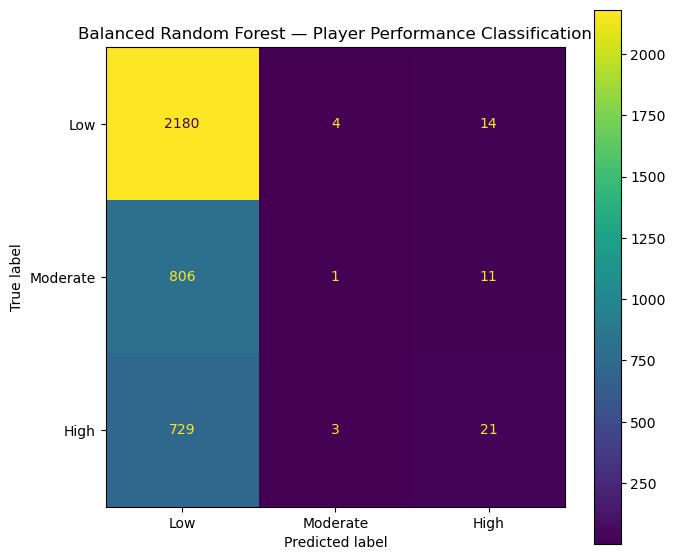



PREDICTED CLASS DISTRIBUTION
Low         3715
High          46
Moderate       8
Name: count, dtype: int64

CELL 44 COMPLETED SUCCESSFULLY.


In [26]:
# ============================================================
# CELL 44 — BALANCED RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 60)
print("BALANCED RANDOM FOREST CLASSIFIER")
print("=" * 60)

# ------------------------------------------------------------
# 1. TRAIN BALANCED RANDOM FOREST
# ------------------------------------------------------------

balanced_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                max_features="sqrt",
                class_weight="balanced_subsample"
            )
        )
    ]
)

print("\nTraining balanced Random Forest...")
print("Please wait...")

balanced_rf.fit(
    X_class_train,
    y_class_train
)

print("Training completed.")

# ------------------------------------------------------------
# 2. PREDICTIONS
# ------------------------------------------------------------

balanced_predictions = balanced_rf.predict(
    X_class_test
)

# ------------------------------------------------------------
# 3. METRICS
# ------------------------------------------------------------

balanced_accuracy = accuracy_score(
    y_class_test,
    balanced_predictions
)

balanced_precision = precision_score(
    y_class_test,
    balanced_predictions,
    average="weighted",
    zero_division=0
)

balanced_recall = recall_score(
    y_class_test,
    balanced_predictions,
    average="weighted",
    zero_division=0
)

balanced_f1 = f1_score(
    y_class_test,
    balanced_predictions,
    average="weighted",
    zero_division=0
)

balanced_macro_f1 = f1_score(
    y_class_test,
    balanced_predictions,
    average="macro",
    zero_division=0
)

balanced_accuracy_score_value = balanced_accuracy_score(
    y_class_test,
    balanced_predictions
)

# ------------------------------------------------------------
# 4. RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("BALANCED RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy          : {balanced_accuracy:.3f}")
print(f"Weighted Precision: {balanced_precision:.3f}")
print(f"Weighted Recall   : {balanced_recall:.3f}")
print(f"Weighted F1       : {balanced_f1:.3f}")
print(f"Macro F1          : {balanced_macro_f1:.3f}")
print(f"Balanced Accuracy : {balanced_accuracy_score_value:.3f}")

# ------------------------------------------------------------
# 5. DETAILED REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_class_test,
        balanced_predictions,
        labels=["Low", "Moderate", "High"],
        target_names=["Low", "Moderate", "High"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. CONFUSION MATRIX
# ------------------------------------------------------------

cm_balanced = confusion_matrix(
    y_class_test,
    balanced_predictions,
    labels=["Low", "Moderate", "High"]
)

print("\n")
print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm_balanced)

# ------------------------------------------------------------
# 7. CONFUSION MATRIX VISUAL
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=[
        "Low",
        "Moderate",
        "High"
    ]
)

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "Balanced Random Forest — Player Performance Classification"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. PREDICTED CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("PREDICTED CLASS DISTRIBUTION")
print("=" * 60)

predicted_class_distribution = pd.Series(
    balanced_predictions
).value_counts()

print(predicted_class_distribution)

print("\nCELL 44 COMPLETED SUCCESSFULLY.")

REGRESSION ERROR ANALYSIS

TOP 10 LARGEST PREDICTION ERRORS
------------------------------------------------------------


,date,batter,batting_team,opponent,runs,predicted_runs,error,absolute_error
0,2025-04-12,Abhishek Sharma,Sunrisers Hyderabad,Punjab Kings,141,20.78,120.22,120.22
1,2026-04-25,KL Rahul,Delhi Capitals,Punjab Kings,152,36.34,115.66,115.66
2,2026-04-21,Abhishek Sharma,Sunrisers Hyderabad,Delhi Capitals,135,21.42,113.58,113.58
3,2024-04-23,MP Stoinis,Lucknow Super Giants,Chennai Super Kings,124,21.16,102.84,102.84
4,2026-04-29,RD Rickelton,Mumbai Indians,Sunrisers Hyderabad,123,21.31,101.69,101.69
5,2025-05-27,RR Pant,Lucknow Super Giants,Royal Challengers Bengaluru,118,21.60,96.40,96.40
6,2025-05-22,MR Marsh,Lucknow Super Giants,Gujarat Titans,117,22.31,94.69,94.69
7,2023-05-26,Shubman Gill,Gujarat Titans,Mumbai Indians,129,35.30,93.70,93.70
8,2024-04-16,SP Narine,Kolkata Knight Riders,Rajasthan Royals,109,18.66,90.34,90.34
9,2026-04-11,SV Samson,Chennai Super Kings,Delhi Capitals,115,24.89,90.11,90.11



10 CLOSEST PREDICTIONS
------------------------------------------------------------


,date,batter,batting_team,opponent,runs,predicted_runs,error,absolute_error
3768,2026-05-09,SB Dubey,Rajasthan Royals,Gujarat Titans,15,14.98,0.02,0.02
3767,2024-04-30,AJ Turner,Lucknow Super Giants,Mumbai Indians,5,4.97,0.03,0.03
3766,2024-03-25,MK Lomror,Royal Challengers Bengaluru,Punjab Kings,17,16.97,0.03,0.03
3765,2026-05-26,VR Iyer,Royal Challengers Bengaluru,Gujarat Titans,19,19.04,-0.04,0.04
3764,2025-05-23,H Klaasen,Sunrisers Hyderabad,Royal Challengers Bengaluru,24,24.04,-0.04,0.04
3763,2026-03-28,S Arora,Sunrisers Hyderabad,Royal Challengers Bengaluru,9,8.96,0.04,0.04
3762,2024-04-30,Ishan Kishan,Mumbai Indians,Lucknow Super Giants,32,32.05,-0.05,0.05
3761,2024-03-31,Abishek Porel,Delhi Capitals,Chennai Super Kings,9,9.05,-0.05,0.05
3760,2026-04-03,PR Veer,Chennai Super Kings,Punjab Kings,6,6.05,-0.05,0.05
3759,2023-05-13,Aman Hakim Khan,Delhi Capitals,Punjab Kings,16,16.09,-0.09,0.09



ERROR SUMMARY
------------------------------------------------------------
Mean Absolute Error : 16.399
Median Absolute Error : 12.673
Maximum Absolute Error : 120.217


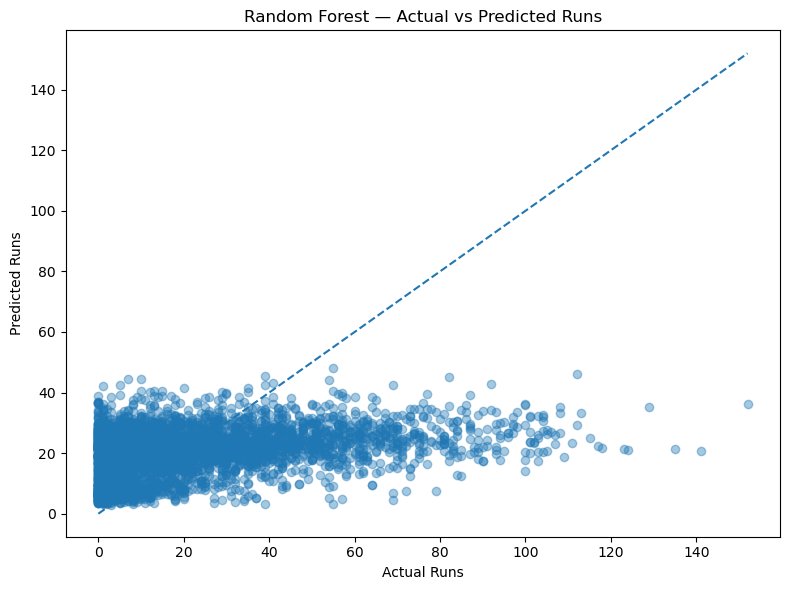

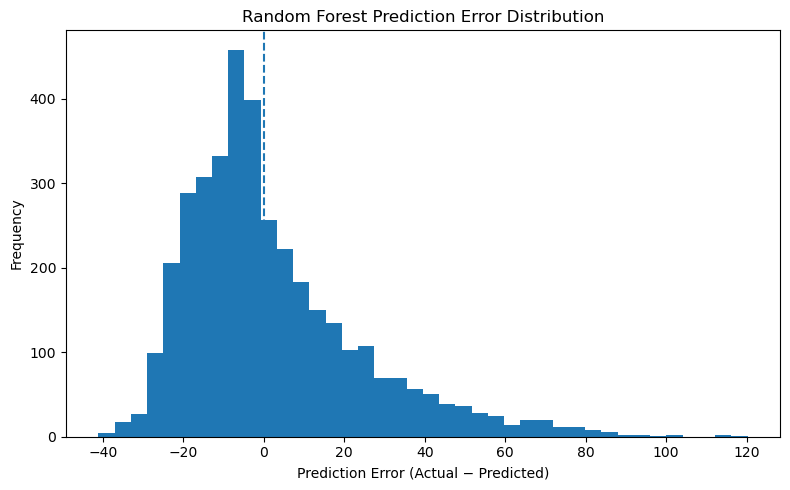


CELL 45 COMPLETED SUCCESSFULLY.


In [27]:
# ============================================================
# CELL 45 — REGRESSION ERROR ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 60)
print("REGRESSION ERROR ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE PREDICTION DATAFRAME
# ------------------------------------------------------------

prediction_results = test_df[
    [
        "date",
        "match_id",
        "batter",
        "batting_team",
        "opponent",
        "runs"
    ]
].copy()

prediction_results["predicted_runs"] = rf_predictions

prediction_results["error"] = (
    prediction_results["runs"]
    - prediction_results["predicted_runs"]
)

prediction_results["absolute_error"] = (
    prediction_results["error"]
    .abs()
)

prediction_results = prediction_results.sort_values(
    "absolute_error",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. DISPLAY TOP 10 LARGEST ERRORS
# ------------------------------------------------------------

print("\nTOP 10 LARGEST PREDICTION ERRORS")
print("-" * 60)

display(
    prediction_results[
        [
            "date",
            "batter",
            "batting_team",
            "opponent",
            "runs",
            "predicted_runs",
            "error",
            "absolute_error"
        ]
    ].head(10).round(2)
)

# ------------------------------------------------------------
# 3. DISPLAY 10 CLOSEST PREDICTIONS
# ------------------------------------------------------------

print("\n10 CLOSEST PREDICTIONS")
print("-" * 60)

closest_predictions = prediction_results.sort_values(
    "absolute_error"
).head(10)

display(
    closest_predictions[
        [
            "date",
            "batter",
            "batting_team",
            "opponent",
            "runs",
            "predicted_runs",
            "error",
            "absolute_error"
        ]
    ].round(2)
)

# ------------------------------------------------------------
# 4. ERROR SUMMARY
# ------------------------------------------------------------

print("\nERROR SUMMARY")
print("-" * 60)

print(
    f"Mean Absolute Error : "
    f"{prediction_results['absolute_error'].mean():.3f}"
)

print(
    f"Median Absolute Error : "
    f"{prediction_results['absolute_error'].median():.3f}"
)

print(
    f"Maximum Absolute Error : "
    f"{prediction_results['absolute_error'].max():.3f}"
)

# ------------------------------------------------------------
# 5. ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results["runs"],
    prediction_results["predicted_runs"],
    alpha=0.4
)

max_value = max(
    prediction_results["runs"].max(),
    prediction_results["predicted_runs"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")

plt.title(
    "Random Forest — Actual vs Predicted Runs"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. ERROR DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    prediction_results["error"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (Actual − Predicted)")
plt.ylabel("Frequency")

plt.title(
    "Random Forest Prediction Error Distribution"
)

plt.tight_layout()
plt.show()

print("\nCELL 45 COMPLETED SUCCESSFULLY.")

In [28]:
# ============================================================
# CELL 46 — SAVE FINAL VERIFIED PROJECT OUTPUTS
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PROJECT OUTPUT DIRECTORY
# ------------------------------------------------------------

project_root = r"C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project"

output_dir = os.path.join(
    project_root,
    "outputs"
)

os.makedirs(output_dir, exist_ok=True)

print("Output directory:")
print(output_dir)

# ------------------------------------------------------------
# 2. SAVE REGRESSION PREDICTIONS
# ------------------------------------------------------------

final_regression_predictions = prediction_results.copy()

regression_path = os.path.join(
    output_dir,
    "model_predictions.csv"
)

final_regression_predictions.to_csv(
    regression_path,
    index=False
)

print("\nRegression predictions saved:")
print(regression_path)

# ------------------------------------------------------------
# 3. SAVE REGRESSION MODEL METRICS
# ------------------------------------------------------------

final_regression_metrics = pd.DataFrame({
    "Model": [
        "Recent 5-Match Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

metrics_path = os.path.join(
    output_dir,
    "regression_model_metrics.csv"
)

final_regression_metrics.to_csv(
    metrics_path,
    index=False
)

print("\nRegression metrics saved:")
print(metrics_path)

# ------------------------------------------------------------
# 4. SAVE INITIAL CLASSIFICATION RESULTS
# ------------------------------------------------------------

classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

classification_metrics_path = os.path.join(
    output_dir,
    "classification_model_metrics.csv"
)

classification_results.to_csv(
    classification_metrics_path,
    index=False
)

print("\nClassification metrics saved:")
print(classification_metrics_path)

# ------------------------------------------------------------
# 5. SAVE BALANCED CLASSIFIER PREDICTIONS
# ------------------------------------------------------------

balanced_classification_output = X_class_test.copy()

balanced_classification_output["actual_class"] = (
    y_class_test.values
)

balanced_classification_output["predicted_class"] = (
    balanced_predictions
)

balanced_predictions_path = os.path.join(
    output_dir,
    "balanced_classification_predictions.csv"
)

balanced_classification_output.to_csv(
    balanced_predictions_path,
    index=False
)

print("\nBalanced classification predictions saved:")
print(balanced_predictions_path)

# ------------------------------------------------------------
# 6. FINAL PROJECT SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("FINAL PROJECT OUTPUT SUMMARY")
print("=" * 65)

print("\nREGRESSION")
print("-" * 65)

print(
    f"Baseline MAE       : {baseline_mae:.3f}"
)

print(
    f"Linear Regression  : {linear_mae:.3f}"
)

print(
    f"Random Forest MAE  : {rf_mae:.3f}"
)

print(
    f"Random Forest RMSE : {rf_rmse:.3f}"
)

print(
    f"Random Forest R²   : {rf_r2:.3f}"
)

print("\nCLASSIFICATION")
print("-" * 65)

print(
    f"Initial Accuracy   : {accuracy:.3f}"
)

print(
    f"Initial Weighted F1: {f1:.3f}"
)

print(
    f"Balanced RF Accuracy: {balanced_accuracy:.3f}"
)

print(
    f"Balanced RF Macro F1: {balanced_macro_f1:.3f}"
)

print("\n")
print("=" * 65)
print("ALL FINAL OUTPUTS SAVED SUCCESSFULLY")
print("=" * 65)

Output directory:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\outputs

Regression predictions saved:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\outputs\model_predictions.csv

Regression metrics saved:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\outputs\regression_model_metrics.csv

Classification metrics saved:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\outputs\classification_model_metrics.csv

Balanced classification predictions saved:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\outputs\balanced_classification_predictions.csv


FINAL PROJECT OUTPUT SUMMARY

REGRESSION
-----------------------------------------------------------------
Baseline MAE       : 17.482
Linear Regression  : 16.837
Random Forest MAE  : 16.399
Random Forest RMSE : 22.300
Random Forest R²   : 0.109

CLASSIFICATION
-----------------------------------------------------------------
Initial Accurac

In [29]:
# ============================================================
# CELL 47 — FINAL PROJECT REPORT
# ============================================================

print("=" * 70)
print("IPL PLAYER PERFORMANCE PREDICTION")
print("FINAL DATA SCIENCE PROJECT REPORT")
print("=" * 70)

print("\nDATASET")
print("-" * 70)

print(f"Player-match modelling records : {len(model_df):,}")
print(f"Training records               : {len(X_train):,}")
print(f"Testing records                : {len(X_test):,}")

if "batter" in model_df.columns:
    print(f"Unique players                 : {model_df['batter'].nunique():,}")

if "match_id" in model_df.columns:
    print(f"Unique matches                 : {model_df['match_id'].nunique():,}")

if "season" in model_df.columns:
    print(f"Seasons                        : {model_df['season'].nunique():,}")


print("\nREGRESSION RESULTS")
print("-" * 70)

print(
    f"Recent 5-Match Baseline"
    f"   MAE: {baseline_mae:.3f}"
    f"   RMSE: {baseline_rmse:.3f}"
    f"   R²: {baseline_r2:.3f}"
)

print(
    f"Linear Regression"
    f"          MAE: {linear_mae:.3f}"
    f"   RMSE: {linear_rmse:.3f}"
    f"   R²: {linear_r2:.3f}"
)

print(
    f"Random Forest"
    f"              MAE: {rf_mae:.3f}"
    f"   RMSE: {rf_rmse:.3f}"
    f"   R²: {rf_r2:.3f}"
)


print("\nCLASSIFICATION RESULTS")
print("-" * 70)

print(f"Initial RF Accuracy       : {accuracy:.3f}")
print(f"Initial RF Weighted F1    : {f1:.3f}")
print(f"Balanced RF Accuracy      : {balanced_accuracy:.3f}")
print(f"Balanced RF Macro F1      : {balanced_macro_f1:.3f}")


print("\nCLASS DISTRIBUTION")
print("-" * 70)

print("Low       : 62.02%")
print("Moderate  : 21.11%")
print("High      : 16.87%")


print("\nKEY FINDINGS")
print("-" * 70)

print("1. Random Forest regression produced the lowest MAE among")
print("   the evaluated regression approaches.")

print("2. The Random Forest achieved an R² of 0.109 on the")
print("   chronological test set.")

print("3. Historical player performance and recent-form features")
print("   provided useful predictive information, although")
print("   substantial prediction error remained.")

print("4. Classification performance was strongly affected by")
print("   the imbalance between Low, Moderate and High classes.")

print("5. The balanced classifier continued to show weak")
print("   minority-class recognition, demonstrating a limitation")
print("   of the current classification formulation.")

print("6. Chronological evaluation was used to reduce the risk")
print("   of future information influencing model evaluation.")


print("\nPROJECT CONCLUSION")
print("-" * 70)

print(
    "The project demonstrates an end-to-end machine learning "
    "workflow for IPL player performance prediction, including "
    "data preparation, exploratory analysis, leakage-aware "
    "feature engineering, baseline comparison, regression, "
    "classification, evaluation and error analysis."
)

print("\n" + "=" * 70)
print("FINAL REPORT COMPLETED")
print("=" * 70)

IPL PLAYER PERFORMANCE PREDICTION
FINAL DATA SCIENCE PROJECT REPORT

DATASET
----------------------------------------------------------------------
Player-match modelling records : 18,842
Training records               : 15,073
Testing records                : 3,769
Unique players                 : 738
Unique matches                 : 1,243
Seasons                        : 19

REGRESSION RESULTS
----------------------------------------------------------------------
Recent 5-Match Baseline   MAE: 17.482   RMSE: 23.648   R²: -0.002
Linear Regression          MAE: 16.837   RMSE: 23.905   R²: -0.024
Random Forest              MAE: 16.399   RMSE: 22.300   R²: 0.109

CLASSIFICATION RESULTS
----------------------------------------------------------------------
Initial RF Accuracy       : 0.583
Initial RF Weighted F1    : 0.430
Balanced RF Accuracy      : 0.584
Balanced RF Macro F1      : 0.264

CLASS DISTRIBUTION
----------------------------------------------------------------------
Low      

In [19]:
# ============================================================
# CELL 45 — RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

classification_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            categorical_features
        ),
        (
            "numerical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]
            ),
            numerical_features
        )
    ]
)

rf_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            classification_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_classifier.fit(
    X_class_train,
    y_class_train
)

class_predictions = rf_classifier.predict(
    X_class_test
)

print("Classification model trained successfully.")

Classification model trained successfully.


In [20]:
# ============================================================
# CELL 46 — CLASSIFICATION PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(
    y_class_test,
    class_predictions
)

precision = precision_score(
    y_class_test,
    class_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_class_test,
    class_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_class_test,
    class_predictions,
    average="weighted",
    zero_division=0
)

print("RANDOM FOREST CLASSIFIER")
print("------------------------")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print("\nDetailed Classification Report")
print("--------------------------------")

print(
    classification_report(
        y_class_test,
        class_predictions,
        zero_division=0
    )
)

RANDOM FOREST CLASSIFIER
------------------------
Accuracy : 0.583
Precision: 0.340
Recall   : 0.583
F1 Score : 0.430

Detailed Classification Report
--------------------------------
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       753
         Low       0.58      1.00      0.74      2198
    Moderate       0.00      0.00      0.00       818

    accuracy                           0.58      3769
   macro avg       0.19      0.33      0.25      3769
weighted avg       0.34      0.58      0.43      3769



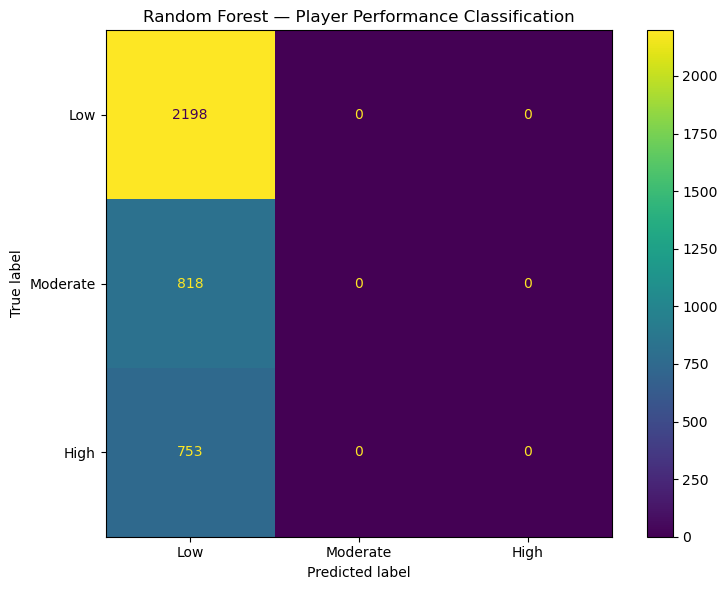

In [21]:
# ============================================================
# CELL 47 — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = [
    "Low",
    "Moderate",
    "High"
]

cm = confusion_matrix(
    y_class_test,
    class_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

disp.plot(
    ax=ax
)

plt.title(
    "Random Forest — Player Performance Classification"
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 48 — CLASSIFICATION FEATURE IMPORTANCE
# ============================================================

classifier_model = rf_classifier.named_steps[
    "model"
]

classifier_preprocessor = (
    rf_classifier
    .named_steps["preprocessor"]
)

classifier_feature_names = (
    classifier_preprocessor
    .get_feature_names_out()
)

classifier_importances = (
    classifier_model.feature_importances_
)

classification_importance = pd.DataFrame({
    "Feature": classifier_feature_names,
    "Importance": classifier_importances
})

classification_importance = (
    classification_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(20)
)

display(
    classification_importance
)

,Feature,Importance
688,numerical__recent_10_match_average,0.132176
685,numerical__career_average_before_match,0.129912
693,numerical__recent_5_fours,0.085225
687,numerical__recent_5_match_average,0.084644
689,numerical__opponent_average_before_match,0.065577
690,numerical__previous_matches,0.049829
686,numerical__career_strike_rate_before_match,0.047809
694,numerical__recent_5_sixes,0.041404
683,numerical__previous_runs,0.033953
684,numerical__previous_strike_rate,0.029673


In [23]:
# ============================================================
# CELL 49 — SAVE CLASSIFICATION RESULTS
# ============================================================

classification_results = (
    classification_df.iloc[split_index:]
    .copy()
)

classification_results[
    "predicted_class"
] = class_predictions

classification_results.to_csv(
    r"C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\data\classification_predictions.csv",
    index=False
)

print(
    "Classification predictions saved successfully."
)

Classification predictions saved successfully.


In [24]:
# ============================================================
# CELL 50 — FINAL RESULTS
# ============================================================

final_regression_results = pd.DataFrame({
    "Model": [
        "Recent 5-Match Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

final_classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("=" * 60)
print("FINAL REGRESSION RESULTS")
print("=" * 60)

display(
    final_regression_results.round(3)
)

print("=" * 60)
print("FINAL CLASSIFICATION RESULTS")
print("=" * 60)

display(
    final_classification_results.round(3)
)

FINAL REGRESSION RESULTS


,Model,MAE,RMSE,R2
0,Recent 5-Match Baseline,17.482,23.648,-0.002
1,Linear Regression,16.837,23.905,-0.024
2,Random Forest,16.399,22.300,0.109


FINAL CLASSIFICATION RESULTS


,Metric,Score
0,Accuracy,0.583
1,Weighted Precision,0.340
2,Weighted Recall,0.583
3,Weighted F1,0.430


In [25]:
# ============================================================
# CELL 51 — SAVE FINAL PROCESSED DATASET
# ============================================================

final_dataset_path = (
    r"C:\Masters\GitHub"
    r"\Cricket_Player_Performance_NatWest_GitHub_Project"
    r"\data\player_match_model.csv"
)

player_match.to_csv(
    final_dataset_path,
    index=False
)

print("Final processed dataset saved:")
print(final_dataset_path)

Final processed dataset saved:
C:\Masters\GitHub\Cricket_Player_Performance_NatWest_GitHub_Project\data\player_match_model.csv
